In [6]:
# pip install gensim
from gensim.models import Word2Vec
import nltk

# Exemple de corpus
corpus = [
    "le chat est sur le tapis".split(),
    "le chien joue dans le jardin".split(),
    "le chat dort sur le canapé".split(),
    "le chien et le chat sont amis".split()
]

# Entrainer Word2Vec (Skip-gram)
model = Word2Vec(
    sentences=corpus,
    vector_size=100,  # Dimension des embeddings
    window=5,  # Context window size
    min_count=1,  # Min word frequency
    sg=1,  # 1=Skip-gram, 0=CBOW
    workers=4  # Parallelization
)

# Acceder au vecteur d'un mot
vector_chat = model.wv['chat']
print(f"Embedding 'chat': {vector_chat}")
print(f"Dimension: {len(vector_chat)}")

# vector_chien = model.wv['chien']
# print(f"Embedding 'chien': {vector_chien}")
# print(f"Dimension: {len(vector_chien)}")

# # Acceder au vecteur d'un mot
# vector_dort = model.wv['dort']
# print(f"Embedding 'dort': {vector_dort}")
# print(f"Dimension: {len(vector_dort)}")

# vector_joue = model.wv['joue']
# print(f"Embedding 'joue': {vector_joue}")
# print(f"Dimension: {len(vector_joue)}")

# Vocabulaire
print(f"Vocabulaire size: {len(model.wv)}")
print(f"Mots: {list(model.wv.index_to_key)}")

Embedding 'chat': [-8.6228391e-03  3.6690566e-03  5.1910211e-03  5.7431026e-03
  7.4686818e-03 -6.1690402e-03  1.1076469e-03  6.0491632e-03
 -2.8394817e-03 -6.1759776e-03 -4.0715959e-04 -8.3686020e-03
 -5.5982573e-03  7.1028927e-03  3.3557413e-03  7.2255833e-03
  6.8028066e-03  7.5294720e-03 -3.7927502e-03 -5.6088151e-04
  2.3492372e-03 -4.5185969e-03  8.3928406e-03 -9.8569971e-03
  6.7623178e-03  2.9156958e-03 -4.9317954e-03  4.3991432e-03
 -1.7395244e-03  6.7114569e-03  9.9655604e-03 -4.3640747e-03
 -6.0068729e-04 -5.6961766e-03  3.8518775e-03  2.7895011e-03
  6.8937722e-03  6.1001568e-03  9.5363213e-03  9.2758350e-03
  7.8994222e-03 -6.9880984e-03 -9.1548488e-03 -3.5659465e-04
 -3.0976248e-03  7.8950506e-03  5.9391870e-03 -1.5459475e-03
  1.5103847e-03  1.7894172e-03  7.8185108e-03 -9.5105730e-03
 -2.0785100e-04  3.4659249e-03 -9.4040466e-04  8.3823213e-03
  9.0116384e-03  6.5395348e-03 -7.0964324e-04  7.7095763e-03
 -8.5348971e-03  3.2081336e-03 -4.6355869e-03 -5.0894171e-03
  3.59

In [7]:
from gensim.models import Word2Vec

model = Word2Vec(sentences=corpus, vector_size=100, min_count=1)

# Similarite entre deux mots
sim = model.wv.similarity('chat', 'chien')
print(f"Similarite(chat, chien) = {sim:.4f}")

# Top N mots similaires
similar_words = model.wv.most_similar('chat', topn=5)
for word, score in similar_words:
    print(f"{word:15} {score:.4f}")

# Distance cosinus (pour les comparaisons)
from scipy.spatial.distance import cosine

v1 = model.wv['chat']
v2 = model.wv['chien']
distance = cosine(v1, v2)  # 1 - similarite
print(f"Distance cosinus: {distance:.4f}")

Similarite(chat, chien) = -0.0237
est             0.1372
sur             0.0682
dort            0.0337
sont            0.0094
joue            0.0083
Distance cosinus: 1.0237


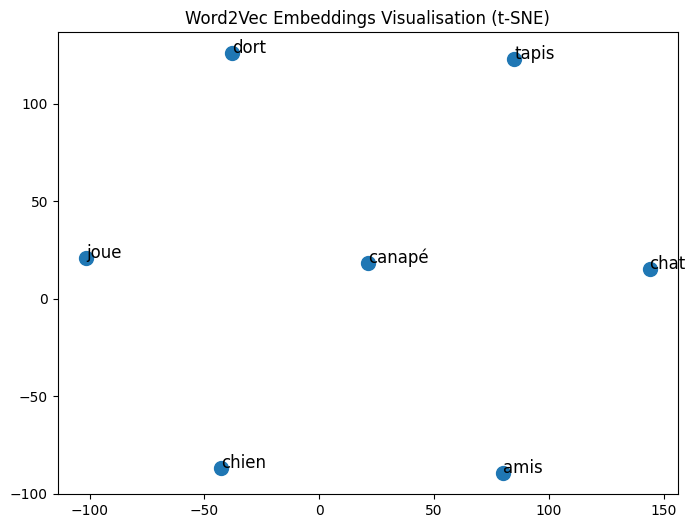

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Extraire les vecteurs du modele
words = ['chat', 'chien', 'dort', 'joue', 'amis', 'canapé', 'tapis']
vectors = np.array([model.wv[word] for word in words])

# t-SNE pour reduction de dimension a 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=6)
vectors_2d = tsne.fit_transform(vectors)

# Visualisation
plt.figure(figsize=(8, 6))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], s=100)
for i, word in enumerate(words):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=12)
plt.title('Word2Vec Embeddings Visualisation (t-SNE)')
plt.show()

In [14]:
from gensim.models import Word2Vec

# Corpus d'entrainement
corpus = [
    "le chat noir dort".split(),
    "le chien bleu court".split(),
    "le chat et le chien jouent".split(),
    "le chat noir dort profondement".split(),
    "le chien bleu court vite".split()
]

# Entrainer Word2Vec (Skip-gram)
model = Word2Vec(
    sentences=corpus,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1  # Skip-gram
)

# Vecteur d'un mot
vector = model.wv['chat']
print(f"Embedding 'chat': {vector[:10]}...")  # Show first 10 dims

# Mots similaires
similar = model.wv.most_similar('chat', topn=3)
print(f"Similaires a 'chat':")
for word, score in similar:
    print(f"  {word}: {score:.4f}")

# Analogies semantiques
result = model.wv.most_similar(
    positive=['chat', 'bleu'],
    negative=['noir'],
    topn=1
)
print(f"\nchat - noir + bleu ≈ {result[0][0]}")

# Similarite cosinus
sim_score = model.wv.similarity('chat', 'chien')
print(f"Similarity(chat, chien): {sim_score:.4f}")

Embedding 'chat': [-0.01723938  0.00733148  0.01037977  0.01148388  0.01493384 -0.01233535
  0.00221123  0.01209456 -0.0056801  -0.01234705]...
Similaires a 'chat':
  bleu: 0.1656
  profondement: 0.1394
  le: 0.1267

chat - noir + bleu ≈ profondement
Similarity(chat, chien): 0.0111


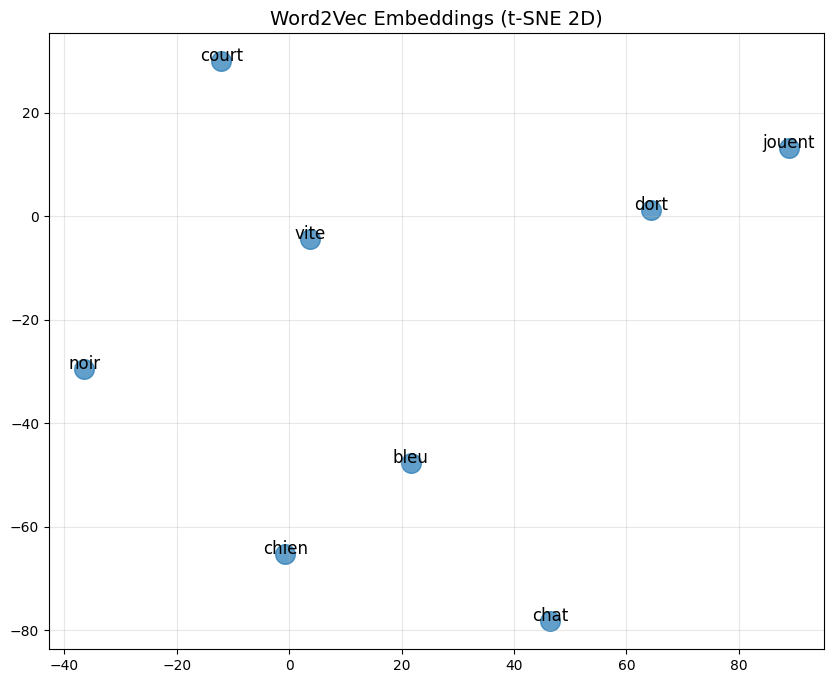

In [15]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Mots a visualiser
words = ['chat', 'chien', 'noir', 'bleu',
         'dort', 'court', 'jouent', 'vite']

# Extraire leurs vecteurs
vectors = np.array([model.wv[word] for word in words])

# t-SNE reduction a 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=3)
vectors_2d = tsne.fit_transform(vectors)

# Visualisation
plt.figure(figsize=(10, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], s=200, alpha=0.7)
for i, word in enumerate(words):
    plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                   fontsize=12, ha='center')
plt.title('Word2Vec Embeddings (t-SNE 2D)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Observations:
# - Animaux (chat, chien) proches ensemble
# - Couleurs (noir, bleu) proches ensemble
# - Verbes (dort, court, joue) proches ensemble